# **KLASIFIKASI_APP TRAVELOKA**

---



Nama:Rinaldi Hamzah

NPM:5220411342

Prodi:Informatika

# **Proyek Integratif Sains Data (CPMK M5)**

Materi Pokok:

1.	Metodologi CRISP-DM

2.	Pipeline sains data: pengumpulan data → eksplorasi → preprocessing → pemodelan → evaluasi

3.	Interpretasi hasil dan penyusunan laporan

Alur Pengerjaan:

1. Load dataset

2. Exploratory Data Analysis (EDA)

3. Preprocessing data

4. Pembangunan dan perbandingan model

5. Evaluasi dan interpretasi hasil

In [ ]:
#Mengakses Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
from wordcloud import WordCloud
import nltk
import requests
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

#### SerpAPI (Scrapping)

In [ ]:
!pip install serpapi

In [ ]:
import serpapi
import os

In [ ]:
from dotenv import load_dotenv

In [ ]:
api_key = "131ab5b32da04cf406eed84d858f5fd6af16f0ff93a2e3868e2b4e868d413f95"

In [ ]:
client = serpapi.Client(api_key=api_key)

In [ ]:
result = client.search(
    engine="google_play_product",
    product_id="com.traveloka.android",   # ID aplikasi
    store="apps",
    all_reviews = True,
    num=199,                     # jumlah review per page (maks 199)
    hl="id",                    # bahasa (id = Indonesia, en = English)
)

In [ ]:
dataReviews = []

for i in result.get("reviews"):
  if i['iso_date'][:4] in ["2023", "2024", "2025"]:
    dataReviews.append(i)

In [ ]:
while "serpapi_pagination" in result:
  result = client.search(
      engine="google_play_product",
      product_id="com.traveloka.android",   # ID aplikasi
      store="apps",
      all_reviews = True,
      num=199,                     # jumlah review per page (maks 199)
      hl="id",                    # bahasa (id = Indonesia, en = English)
      next_page_token = result.get('serpapi_pagination')['next_page_token']
  )
  for i in result.get('reviews'):
    if i['iso_date'][:4] in ["2023", "2024", "2025"]:
      dataReviews.append(i)
  print(len(dataReviews))
  if len(dataReviews) > 1200:
    break

398
587
718
819
875
942
1013
1070
1108
1126
1154
1210


In [ ]:
result.get('reviews')[0]

{'id': '7d72c2d6-3aa5-461c-8672-8669a403319a',
 'title': 'Pengguna Google',
 'avatar': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g',
 'rating': 5.0,
 'snippet': 'terima kasih yang sebesar besarnya. karena aplikasi ini sangat membantu keuangan dalam membeli dan mencari tiket. sangat bagus. memberikan solusi dengan egektif dan tepat. semua pelayanan ramah dan sangat baik. saya berharap traveloka selalu terdepan dan tetap no 1 dihati masyarakat. dan masih banyak lagi kejutan2 untuk kedepannya. semoga selalu sukses dan berjaya sampai kapanpun. terima kasih sy yang sangat besar buat traveloka 😘😘😘',
 'likes': 0,
 'date': 'February 05, 2019',
 'iso_date': '2019-02-05T01:50:08Z'}

In [ ]:
dataReviews[0]['iso_date'][:4] in ["2025"]

True

In [ ]:
df = pd.DataFrame(dataReviews)

In [ ]:
df

,id,title,avatar,rating,snippet,likes,date,iso_date,response
0,56acae6e-1c0b-4f5c-b0f4-08c23fcfac04,Nabilla Puspa,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,Pesanan hotel di batalkan sepihak dan status d...,8,"November 26, 2025",2025-11-26T23:09:19Z,"{'title': 'Traveloka', 'snippet': 'Hai Nabilla..."
1,1c3cb300-2e11-4f8f-988d-49c1f02c531f,Rico Jutindharo,https://play-lh.googleusercontent.com/a/ACg8oc...,1.0,punya kredit limit (alias limit mencukupi)tapi...,4,"November 29, 2025",2025-11-29T17:31:14Z,"{'title': 'Traveloka', 'snippet': 'Hai Rico, k..."
2,dbe4ad54-ed7f-4507-afa9-b34dad41b576,Sholikhun Nindhom,https://play-lh.googleusercontent.com/a/ACg8oc...,1.0,"Proses verifikasi payment gajelas, udah paymen...",18,"November 17, 2025",2025-11-17T06:46:25Z,"{'title': 'Traveloka', 'snippet': 'Hai Sholikh..."
3,5da01634-103f-4c19-a292-477129811e5e,Bagus Rizki,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,Sangat kecewa dengan Traveloka. Tiket saya dib...,16,"November 25, 2025",2025-11-25T08:03:54Z,"{'title': 'Traveloka', 'snippet': 'Hai Bagus, ..."
4,98f38e49-bc2c-4fd6-860b-dd6fb0b6ed1a,Ardiansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,"pemberitahuan reschedule penerbangan berubah"" ...",0,"December 01, 2025",2025-12-01T15:10:33Z,"{'title': 'Traveloka', 'snippet': 'Hai Ardians..."
...,...,...,...,...,...,...,...,...,...
1205,7e250e8b-f84c-4d8e-a1a8-d26fb57bfe88,Deri Murpi,https://play-lh.googleusercontent.com/a/ACg8oc...,1.0,Sangat gak berguna sih untuk limit di luar Tpa...,193,"December 21, 2024",2024-12-21T08:01:25Z,"{'title': 'Traveloka', 'snippet': 'Hai Deri, m..."
1206,ddfa5fde-3341-482e-8494-716797ab70a3,Febi,https://play-lh.googleusercontent.com/a/ACg8oc...,1.0,Parah banget pihak traveloka. Tiba2 saya dapat...,14,"August 17, 2024",2024-08-17T12:27:32Z,"{'title': 'Traveloka', 'snippet': 'Hai Febii. ..."
1207,375994e5-9b61-4a94-bf61-ef962d6c3af7,Andi Orlanda,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,Saya kecewa dengan Aplikasi traveloka yg sekar...,79,"September 15, 2024",2024-09-15T00:08:49Z,"{'title': 'Traveloka', 'snippet': 'Hai Andi, k..."
1208,e7c78a53-b869-4144-8e05-52957aa6c182,Kenzi Ltfh,https://play-lh.googleusercontent.com/a/ACg8oc...,5.0,Traveloka memang solusi yang sangat di percaya...,1,"October 25, 2023",2023-10-25T08:11:20Z,"{'title': 'Traveloka', 'snippet': 'Halo Kak, t..."


In [ ]:
df['iso_date'][0]

'2025-11-26T23:09:19Z'

In [ ]:
df.to_csv("dataset_traveloka(2023-2025).csv", index = False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        1210 non-null   object 
 1   title     1210 non-null   object 
 2   avatar    1210 non-null   object 
 3   rating    1210 non-null   float64
 4   snippet   1210 non-null   object 
 5   likes     1210 non-null   int64  
 6   date      1210 non-null   object 
 7   iso_date  1210 non-null   object 
 8   response  1197 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 85.2+ KB


In [ ]:
df2 = df[['rating', 'snippet', 'likes']]

In [ ]:
df2.to_csv("dataset_traveloka_dropped(2023-2025).csv", index = False)

#### Pengumpulan Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Semester7 2026/Pemrosesan Teks/Analisis Sentimen App Traveloka di Play Store/traveloka.csv")
df

,rating,snippet,likes,sentiment
0,1,MENDADAK LIMIT TURUN SAMPAI DI 0 padahal aktif...,24,Negatif
1,1,Sangat kecewa dengan Traveloka. Tiket saya dib...,11,Negatif
2,1,"Proses verifikasi payment gajelas, udah paymen...",16,Negatif
3,1,untuk menu penjualan tiket dan akomodasinya us...,18,Netral
4,1,poin yg dapat dr tiap beli tiket terlalu banya...,10,Positif
...,...,...,...,...
1388,5,sangat baik cara penyampaiannya,0,Positif
1389,5,Proses transaksi mudah dan lancar,0,Positif
1390,5,sangat membantu sekali sejak adanya paylater,0,Positif
1391,1,"Turun ke bintang 1, pertama : sistem paylater ...",188,Negatif


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1393 entries, 0 to 1392
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   rating     1393 non-null   int64 
 1   snippet    1393 non-null   object
 2   likes      1393 non-null   int64 
 3   sentiment  1393 non-null   object
dtypes: int64(2), object(2)
memory usage: 43.7+ KB


In [ ]:
df = df.drop(['rating', 'likes'], axis = 1)

In [ ]:
total_negatif = len(df[df['sentiment'] == "Negatif"])
total_positif = len(df[df['sentiment'] == "Positif"])
total_netral = len(df[df['sentiment'] == "Netral"])

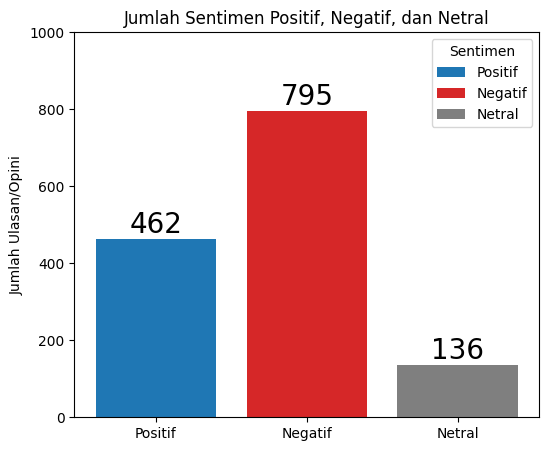

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

fruits = ['Positif', 'Negatif', 'Netral']
counts = [total_positif, total_negatif, total_netral]
bar_labels = fruits
bar_colors = ['tab:blue', 'tab:red', 'tab:gray']

bar_container = ax.bar(fruits, counts, label=bar_labels, color=bar_colors)
ax.bar_label(bar_container, size = 20)

ax.set_ylim(0, 1000)
ax.set_ylabel('Jumlah Ulasan/Opini')
ax.set_title('Jumlah Sentimen Positif, Negatif, dan Netral')
ax.legend(title='Sentimen')

plt.show()

#### Preprocessing

##### Pembersihan

In [ ]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
def bersihkan_teks(teks):
    teks = re.sub(r'@\w+', ' ', teks)                                           # Menghapus metion/username
    teks = url_pattern.sub(' ', teks)                                           # Menghapus url/link
    teks = re.sub(r'[Tt]_[Tt]', ' kecewa ', teks)                               # Jika terdapat T_T dalam teks, dikonversi jadi kata kecewa
    teks = re.sub(r'[>][:][(]', ' kesal ', teks)                                # Jika terdapat >:( dalam teks, dikonversi jadi kata kesal
    teks = re.sub(r'[Bb][Ii][Nn][Tt][Aa][Nn][Gg]\s1', ' bintang satu ', teks)   # Jika terdapat bintang 1, dikonversi jadi kata bintang satu
    teks = re.sub(r'[Bb][Ii][Nn][Tt][Aa][Nn][Gg]\s2', ' bintang dua ', teks)    # Jika terdapat bintang 1, dikonversi jadi kata bintang dua
    teks = re.sub(r'[Bb][Ii][Nn][Tt][Aa][Nn][Gg]\s3', ' bintang tiga ', teks)   # Jika terdapat bintang 1, dikonversi jadi kata bintang tiga
    teks = re.sub(r'[Bb][Ii][Nn][Tt][Aa][Nn][Gg]\s4', ' bintang empat ', teks)  # Jika terdapat bintang 1, dikonversi jadi kata bintang empat
    teks = re.sub(r'[Bb][Ii][Nn][Tt][Aa][Nn][Gg]\s5', ' bintang lima ', teks)   # Jika terdapat bintang 1, dikonversi jadi kata bintang lima
    teks = re.sub(r'[^a-zA-Z\s]', ' ', teks)                                    # Hapus angka, simbol, hastag, mention
    teks = re.sub(r'\s+', ' ', teks)                                            # Ganti spasi berlebih dengan satu spasi
    teks = teks.strip()                                                         # Hapus spasi di awal/akhir
    teks = teks.lower()                                                         # Semua huruf dijadikan huruf kecil
    return teks

In [ ]:
df['snippet'] = df['snippet'].apply(lambda x: bersihkan_teks(x))

In [ ]:
df

,snippet,sentiment
0,mendadak limit turun sampai di padahal aktif d...,Negatif
1,sangat kecewa dengan traveloka tiket saya diba...,Negatif
2,proses verifikasi payment gajelas udah payment...,Negatif
3,untuk menu penjualan tiket dan akomodasinya us...,Netral
4,poin yg dapat dr tiap beli tiket terlalu banya...,Positif
...,...,...
1388,sangat baik cara penyampaiannya,Positif
1389,proses transaksi mudah dan lancar,Positif
1390,sangat membantu sekali sejak adanya paylater,Positif
1391,turun ke bintang satu pertama sistem paylater ...,Negatif


##### Tokenizing

In [ ]:
df['tokenize'] = df['snippet'].apply(lambda x: x.split())

In [ ]:
df

,snippet,sentiment,tokenize
0,mendadak limit turun sampai di padahal aktif d...,Negatif,"[mendadak, limit, turun, sampai, di, padahal, ..."
1,sangat kecewa dengan traveloka tiket saya diba...,Negatif,"[sangat, kecewa, dengan, traveloka, tiket, say..."
2,proses verifikasi payment gajelas udah payment...,Negatif,"[proses, verifikasi, payment, gajelas, udah, p..."
3,untuk menu penjualan tiket dan akomodasinya us...,Netral,"[untuk, menu, penjualan, tiket, dan, akomodasi..."
4,poin yg dapat dr tiap beli tiket terlalu banya...,Positif,"[poin, yg, dapat, dr, tiap, beli, tiket, terla..."
...,...,...,...
1388,sangat baik cara penyampaiannya,Positif,"[sangat, baik, cara, penyampaiannya]"
1389,proses transaksi mudah dan lancar,Positif,"[proses, transaksi, mudah, dan, lancar]"
1390,sangat membantu sekali sejak adanya paylater,Positif,"[sangat, membantu, sekali, sejak, adanya, payl..."
1391,turun ke bintang satu pertama sistem paylater ...,Negatif,"[turun, ke, bintang, satu, pertama, sistem, pa..."


##### Normalisasi kata

In [ ]:
df_normal= pd.read_csv("/content/drive/MyDrive/Semester7 2026/Pemrosesan Teks/Analisis Sentimen App Traveloka di Play Store/list_normalisasi.csv", sep=';')

In [ ]:
df_normal

,awal,normalisasi
0,gw,saya
1,gue,saya
2,dri,dari
3,ga,tidak
4,paylatter,paylater
...,...,...
320,sudh,sudah
321,pernh,pernah
322,gua,saya
323,bsa,bisa


In [ ]:
dict_normal = dict(
    zip(df_normal['awal'], df_normal['normalisasi'])
)

In [ ]:
def normalize_text(tokens):
    return [dict_normal.get(token, token) for token in tokens]

In [ ]:
df['normalisasi'] = df['tokenize'].apply(normalize_text)

In [ ]:
df

,snippet,sentiment,tokenize,normalisasi
0,mendadak limit turun sampai di padahal aktif d...,Negatif,"[mendadak, limit, turun, sampai, di, padahal, ...","[mendadak, limit, turun, sampai, di, padahal, ..."
1,sangat kecewa dengan traveloka tiket saya diba...,Negatif,"[sangat, kecewa, dengan, traveloka, tiket, say...","[sangat, kecewa, dengan, traveloka, tiket, say..."
2,proses verifikasi payment gajelas udah payment...,Negatif,"[proses, verifikasi, payment, gajelas, udah, p...","[proses, verifikasi, payment, tidak jelas, sud..."
3,untuk menu penjualan tiket dan akomodasinya us...,Netral,"[untuk, menu, penjualan, tiket, dan, akomodasi...","[untuk, menu, penjualan, tiket, dan, akomodasi..."
4,poin yg dapat dr tiap beli tiket terlalu banya...,Positif,"[poin, yg, dapat, dr, tiap, beli, tiket, terla...","[poin, yang, dapat, dari, setiap, beli, tiket,..."
...,...,...,...,...
1388,sangat baik cara penyampaiannya,Positif,"[sangat, baik, cara, penyampaiannya]","[sangat, baik, cara, penyampaiannya]"
1389,proses transaksi mudah dan lancar,Positif,"[proses, transaksi, mudah, dan, lancar]","[proses, transaksi, mudah, dan, lancar]"
1390,sangat membantu sekali sejak adanya paylater,Positif,"[sangat, membantu, sekali, sejak, adanya, payl...","[sangat, membantu, sekali, sejak, adanya, payl..."
1391,turun ke bintang satu pertama sistem paylater ...,Negatif,"[turun, ke, bintang, satu, pertama, sistem, pa...","[turun, ke, bintang, satu, pertama, sistem, pa..."


Lematisasi

In [ ]:
def stem_word(word):
    """Menghapus awalan dan akhiran umum Bahasa Indonesia secara sederhana"""
    prefixes = ['meng', 'meny', 'men', 'mem', 'me',
                'peng', 'peny', 'pen', 'pem', 'di', 'ke', 'se',
                'ber', 'ter', 'per']
    suffixes = ['kan', 'an', 'i', 'lah', 'nya', 'ku', 'mu']
    for p in prefixes:
        if word.startswith(p) and len(word) > len(p) + 2:
            word = word[len(p):]
            break

    for s in suffixes:
        if word.endswith(s) and len(word) > len(s) + 2:
            word = word[:-len(s)]
            break
    return word

def stem_sentence(sentence):
    return " ".join([stem_word(w) for w in sentence.split()])
df['lemmatisasi'] = df['normalisasi'].astype(str).apply(stem_sentence)

In [ ]:
df

,snippet,sentiment,tokenize,normalisasi,lemmatisasi
0,mendadak limit turun sampai di padahal aktif d...,Negatif,"[mendadak, limit, turun, sampai, di, padahal, ...","[mendadak, limit, turun, sampai, di, padahal, ...","['mendadak', 'limit', 'turun', 'sampai', 'di',..."
1,sangat kecewa dengan traveloka tiket saya diba...,Negatif,"[sangat, kecewa, dengan, traveloka, tiket, say...","[sangat, kecewa, dengan, traveloka, tiket, say...","['sangat', 'kecewa', 'dengan', 'traveloka', 't..."
2,proses verifikasi payment gajelas udah payment...,Negatif,"[proses, verifikasi, payment, gajelas, udah, p...","[proses, verifikasi, payment, tidak jelas, sud...","['proses', 'verifikasi', 'payment', 'tidak jel..."
3,untuk menu penjualan tiket dan akomodasinya us...,Netral,"[untuk, menu, penjualan, tiket, dan, akomodasi...","[untuk, menu, penjualan, tiket, dan, akomodasi...","['untuk', 'menu', 'penjualan', 'tiket', 'dan',..."
4,poin yg dapat dr tiap beli tiket terlalu banya...,Positif,"[poin, yg, dapat, dr, tiap, beli, tiket, terla...","[poin, yang, dapat, dari, setiap, beli, tiket,...","['poin', 'yang', 'dapat', 'dari', 'setiap', 'b..."
...,...,...,...,...,...
1388,sangat baik cara penyampaiannya,Positif,"[sangat, baik, cara, penyampaiannya]","[sangat, baik, cara, penyampaiannya]","['sangat', 'baik', 'cara', 'penyampaiannya']"
1389,proses transaksi mudah dan lancar,Positif,"[proses, transaksi, mudah, dan, lancar]","[proses, transaksi, mudah, dan, lancar]","['proses', 'transaksi', 'mudah', 'dan', 'lancar']"
1390,sangat membantu sekali sejak adanya paylater,Positif,"[sangat, membantu, sekali, sejak, adanya, payl...","[sangat, membantu, sekali, sejak, adanya, payl...","['sangat', 'membantu', 'sekali', 'sejak', 'ada..."
1391,turun ke bintang satu pertama sistem paylater ...,Negatif,"[turun, ke, bintang, satu, pertama, sistem, pa...","[turun, ke, bintang, satu, pertama, sistem, pa...","['turun', 'ke', 'bintang', 'satu', 'pertama', ..."


##### Stopwords

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('indonesian'))
stop_list = ["waaa", "dong", "sih", "wkwkwkw", "ah", "deh", "kok", "ny", "nya",
             "pun", "wkwk", "lah", "sll", "donk", "yaa", "doank", "hehehe", "oya",
             "dech", "nich", "ehh", "ya", "ribu", "a"]

remove_stop_list = ["kurang", "masalah", "lama", "jauh", "tapi", "keterlaluan",
                    "baik"]

stop_words.update(stop_list)

for i in remove_stop_list:
  stop_words.remove(i)

In [ ]:
df['stopwords'] = df['normalisasi'].apply(lambda tokens: [word for word in tokens if word not in stop_words])

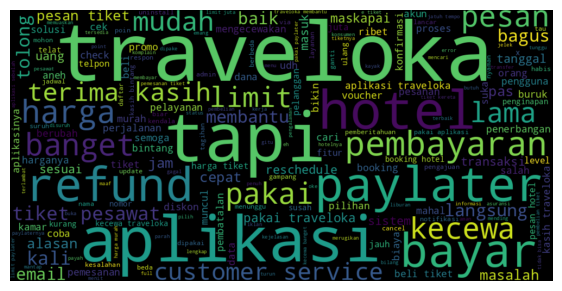

In [ ]:
all_text = ' '.join([" ".join(word) for word in df['stopwords']])
wordcloud = WordCloud(width=1000, height=500, max_font_size=150, random_state=42).generate(all_text)
plt.figure(figsize=(7,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

##### Stemming

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
df_cus_stem_list = pd.read_csv("/content/drive/MyDrive/Semester7 2026/Pemrosesan Teks/Analisis Sentimen App Traveloka di Play Store/list_stemming.csv", sep=';')

In [ ]:
custom_stem = {}

In [ ]:
for awal_kata, stem_kata in zip(df_cus_stem_list['awal'], df_cus_stem_list['stemming']):
  if awal_kata not in custom_stem:
    custom_stem[awal_kata] = stem_kata

In [ ]:
def safe_stem(word):
    if word in custom_stem:
        return custom_stem[word]
    return stemmer.stem(word)

In [ ]:
safe_stem("mengurangi")

'kurang'

In [ ]:
df['stemming'] = df['stopwords'].apply(lambda x: [safe_stem(word) for word in x])

In [ ]:
df

,snippet,sentiment,tokenize,normalisasi,lemmatisasi,stopwords,stemming
0,mendadak limit turun sampai di padahal aktif d...,Negatif,"[mendadak, limit, turun, sampai, di, padahal, ...","[mendadak, limit, turun, sampai, di, padahal, ...","['mendadak', 'limit', 'turun', 'sampai', 'di',...","[mendadak, limit, turun, aktif, transaksi, pem...","[dadak, limit, turun, aktif, transaksi, bayar,..."
1,sangat kecewa dengan traveloka tiket saya diba...,Negatif,"[sangat, kecewa, dengan, traveloka, tiket, say...","[sangat, kecewa, dengan, traveloka, tiket, say...","['sangat', 'kecewa', 'dengan', 'traveloka', 't...","[kecewa, traveloka, tiket, dibatalkan, maskapa...","[kecewa, traveloka, tiket, batal, maskapai, ta..."
2,proses verifikasi payment gajelas udah payment...,Negatif,"[proses, verifikasi, payment, gajelas, udah, p...","[proses, verifikasi, payment, tidak jelas, sud...","['proses', 'verifikasi', 'payment', 'tidak jel...","[proses, verifikasi, payment, tidak jelas, pay...","[proses, verifikasi, payment, tidak jelas, pay..."
3,untuk menu penjualan tiket dan akomodasinya us...,Netral,"[untuk, menu, penjualan, tiket, dan, akomodasi...","[untuk, menu, penjualan, tiket, dan, akomodasi...","['untuk', 'menu', 'penjualan', 'tiket', 'dan',...","[menu, penjualan, tiket, akomodasinya, lumayan...","[menu, jual, tiket, akomodasi, lumayan, tapi, ..."
4,poin yg dapat dr tiap beli tiket terlalu banya...,Positif,"[poin, yg, dapat, dr, tiap, beli, tiket, terla...","[poin, yang, dapat, dari, setiap, beli, tiket,...","['poin', 'yang', 'dapat', 'dari', 'setiap', 'b...","[poin, beli, tiket, tolong, dikurangi, rp, tra...","[poin, beli, tiket, tolong, kurang, rp, transa..."
...,...,...,...,...,...,...,...
1388,sangat baik cara penyampaiannya,Positif,"[sangat, baik, cara, penyampaiannya]","[sangat, baik, cara, penyampaiannya]","['sangat', 'baik', 'cara', 'penyampaiannya']","[baik, penyampaiannya]","[baik, sampai]"
1389,proses transaksi mudah dan lancar,Positif,"[proses, transaksi, mudah, dan, lancar]","[proses, transaksi, mudah, dan, lancar]","['proses', 'transaksi', 'mudah', 'dan', 'lancar']","[proses, transaksi, mudah, lancar]","[proses, transaksi, mudah, lancar]"
1390,sangat membantu sekali sejak adanya paylater,Positif,"[sangat, membantu, sekali, sejak, adanya, payl...","[sangat, membantu, sekali, sejak, adanya, payl...","['sangat', 'membantu', 'sekali', 'sejak', 'ada...","[membantu, paylater]","[membantu, paylater]"
1391,turun ke bintang satu pertama sistem paylater ...,Negatif,"[turun, ke, bintang, satu, pertama, sistem, pa...","[turun, ke, bintang, satu, pertama, sistem, pa...","['turun', 'ke', 'bintang', 'satu', 'pertama', ...","[turun, bintang, sistem, paylater, skor, merah...","[turun, bintang, sistem, paylater, skor, merah..."


##### Label Encoding

In [ ]:
label_col = 'sentiment'  # ganti sesuai hasil df.columns

dict_label_sentimen = {}
label_classes = []
index = 0

for label in df[label_col]:
    if label not in dict_label_sentimen:
        dict_label_sentimen[label] = index
        label_classes.append(label)
        index += 1

In [ ]:
df['sentiment_encoded'] = df['sentiment'].apply(lambda x: dict_label_sentimen[x])

In [ ]:
dict_label_sentimen

{'Negatif': 0, 'Netral': 1, 'Positif': 2}

In [ ]:
df

,snippet,sentiment,tokenize,normalisasi,lemmatisasi,stopwords,stemming,sentiment_encoded
0,mendadak limit turun sampai di padahal aktif d...,Negatif,"[mendadak, limit, turun, sampai, di, padahal, ...","[mendadak, limit, turun, sampai, di, padahal, ...","['mendadak', 'limit', 'turun', 'sampai', 'di',...","[mendadak, limit, turun, aktif, transaksi, pem...","[dadak, limit, turun, aktif, transaksi, bayar,...",0
1,sangat kecewa dengan traveloka tiket saya diba...,Negatif,"[sangat, kecewa, dengan, traveloka, tiket, say...","[sangat, kecewa, dengan, traveloka, tiket, say...","['sangat', 'kecewa', 'dengan', 'traveloka', 't...","[kecewa, traveloka, tiket, dibatalkan, maskapa...","[kecewa, traveloka, tiket, batal, maskapai, ta...",0
2,proses verifikasi payment gajelas udah payment...,Negatif,"[proses, verifikasi, payment, gajelas, udah, p...","[proses, verifikasi, payment, tidak jelas, sud...","['proses', 'verifikasi', 'payment', 'tidak jel...","[proses, verifikasi, payment, tidak jelas, pay...","[proses, verifikasi, payment, tidak jelas, pay...",0
3,untuk menu penjualan tiket dan akomodasinya us...,Netral,"[untuk, menu, penjualan, tiket, dan, akomodasi...","[untuk, menu, penjualan, tiket, dan, akomodasi...","['untuk', 'menu', 'penjualan', 'tiket', 'dan',...","[menu, penjualan, tiket, akomodasinya, lumayan...","[menu, jual, tiket, akomodasi, lumayan, tapi, ...",1
4,poin yg dapat dr tiap beli tiket terlalu banya...,Positif,"[poin, yg, dapat, dr, tiap, beli, tiket, terla...","[poin, yang, dapat, dari, setiap, beli, tiket,...","['poin', 'yang', 'dapat', 'dari', 'setiap', 'b...","[poin, beli, tiket, tolong, dikurangi, rp, tra...","[poin, beli, tiket, tolong, kurang, rp, transa...",2
...,...,...,...,...,...,...,...,...
1388,sangat baik cara penyampaiannya,Positif,"[sangat, baik, cara, penyampaiannya]","[sangat, baik, cara, penyampaiannya]","['sangat', 'baik', 'cara', 'penyampaiannya']","[baik, penyampaiannya]","[baik, sampai]",2
1389,proses transaksi mudah dan lancar,Positif,"[proses, transaksi, mudah, dan, lancar]","[proses, transaksi, mudah, dan, lancar]","['proses', 'transaksi', 'mudah', 'dan', 'lancar']","[proses, transaksi, mudah, lancar]","[proses, transaksi, mudah, lancar]",2
1390,sangat membantu sekali sejak adanya paylater,Positif,"[sangat, membantu, sekali, sejak, adanya, payl...","[sangat, membantu, sekali, sejak, adanya, payl...","['sangat', 'membantu', 'sekali', 'sejak', 'ada...","[membantu, paylater]","[membantu, paylater]",2
1391,turun ke bintang satu pertama sistem paylater ...,Negatif,"[turun, ke, bintang, satu, pertama, sistem, pa...","[turun, ke, bintang, satu, pertama, sistem, pa...","['turun', 'ke', 'bintang', 'satu', 'pertama', ...","[turun, bintang, sistem, paylater, skor, merah...","[turun, bintang, sistem, paylater, skor, merah...",0


In [ ]:
# df.to_csv('traveloka_final.csv', index=False)

#### Pembagian dataset

In [ ]:
X = df['stemming'].to_numpy()
y = df['sentiment_encoded'].to_numpy()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
sentiment_counts = {
    'Positif': np.array([0, 0]),
    'Negatif': np.array([0, 0]),
    'Netral': np.array([0, 0])
}

In [ ]:
for label in y_train:
  sentiment_counts[label_classes[label]][0] += 1

for label in y_test:
  sentiment_counts[label_classes[label]][1] += 1

In [ ]:
sentiment_counts[label_classes[label]]

array([636, 159])

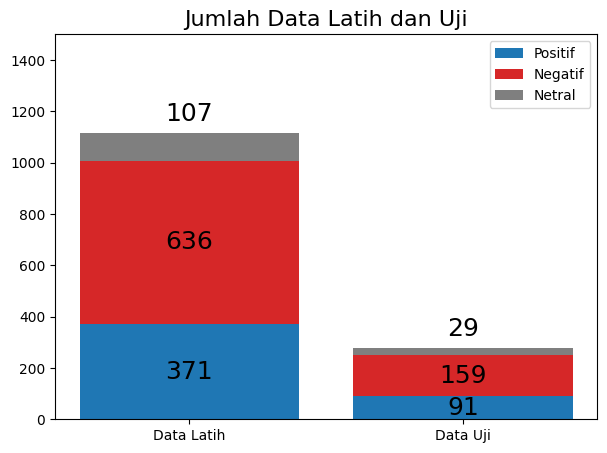

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
bottom = np.zeros(2)
index_color = 0
data_horizontal = ('Data Latih', 'Data Uji')
bar_colors = ['tab:blue', 'tab:red', 'tab:gray']
width = 0.8  # the width of the bars: can also be len(x) sequence

for label, jumlah_sentimen in sentiment_counts.items():
    p = ax.bar(data_horizontal, jumlah_sentimen, width, label=label, bottom=bottom, color=bar_colors[index_color])

    if label == "Netral":
        # tampilkan di bagian atas (edge) dengan sedikit jarak
        ax.bar_label(p, labels=[f"{v:.0f}" for v in jumlah_sentimen],
                     label_type='edge', padding=5, color='black', size=18)
    else:
        ax.bar_label(p, labels=[f"{v:.0f}" for v in jumlah_sentimen],
                     label_type='center', color='black', size=18)

    bottom += jumlah_sentimen
    index_color += 1

ax.set_title('Jumlah Data Latih dan Uji', fontsize=16)
ax.legend()
ax.set_ylim(0, 1500)

plt.show()


#### Ekstrasi Fitur (TF-IDF)

In [ ]:
# X_train_text = [" ".join(tokens) for tokens in X_train]
# X_test_text = [" ".join(tokens) for tokens in X_test]

In [ ]:
tfidf = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None
)

In [ ]:
tfidf.fit(X_train)

TfidfVectorizer(preprocessor=<function <lambda> at 0x7aae3dada7a0>,
                token_pattern=None,
                tokenizer=<function <lambda> at 0x7aae3dadb380>)

In [ ]:
tfidf.get_feature_names_out()

array(['abal', 'absolute', 'ac', ..., 'zaman', 'zona', 'zoo'],
      dtype=object)

In [ ]:
X_train = tfidf.transform(X_train)
X_test = tfidf.transform(X_test)

#### Klasifikasi dengan menggunakan Decision Tree

##### Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import GridSearchCV

Tuning

1.   criterion = entropy
2.   random_state = 0

In [ ]:
param_grid = {
    'max_depth': [10, 12, 14, 18, 19, 20],
    'min_samples_split': [4, 5, 6, 8, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Best Estimator:", grid.best_estimator_)

Best Parameters: {'criterion': 'gini', 'max_depth': 19, 'min_samples_split': 4}
Best CV Score: 0.7567244374419262
Best Estimator: DecisionTreeClassifier(max_depth=19, min_samples_split=4, random_state=42)


In [ ]:
model_decision_tree = DecisionTreeClassifier(
    criterion="entropy", random_state=0, max_depth=1, min_samples_split = 12
    )

In [ ]:
model_decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=1, min_samples_split=12,
                       random_state=0)

##### Testing dan Hasil evaluasi

In [ ]:
y_pred = model_decision_tree.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
y_test

array([1, 0, 0, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 1, 2, 0, 0, 0, 2, 1, 0, 0,
       0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0,
       2, 2, 0, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 0, 0, 1,
       0, 0, 2, 2, 2, 1, 2, 0, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0, 2,
       0, 2, 2, 1, 2, 0, 2, 0, 0, 0, 1, 0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 2,
       0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 1, 0, 0, 0, 0, 2, 2,
       0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 1, 2, 0, 2, 0,
       0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 0, 1, 2, 0, 1, 0, 1, 0, 2,
       2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 2,
       2, 0, 2, 2, 2, 1, 0, 2, 2, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0, 0, 0, 0,
       2, 0, 2, 2, 1, 2, 2, 0, 1, 0, 2, 0, 0, 0, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

0.6487455197132617

Akurasi: 0.6487455197132617

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.62      0.99      0.77       159
      Netral       0.00      0.00      0.00        29
     Positif       0.92      0.25      0.40        91

    accuracy                           0.65       279
   macro avg       0.51      0.42      0.39       279
weighted avg       0.65      0.65      0.57       279



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


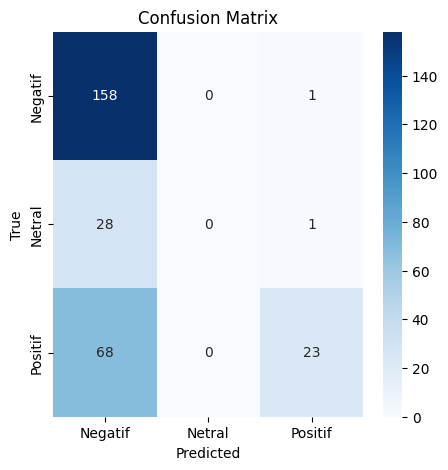

In [ ]:
# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_classes,
            yticklabels=label_classes,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
tfidf.get_feature_names_out()

array(['abal', 'absolute', 'ac', ..., 'zaman', 'zona', 'zoo'],
      dtype=object)

In [ ]:
nama_fitur = tfidf.get_feature_names_out()
dot_data = export_graphviz(model_decision_tree, out_file=None, feature_names=nama_fitur,
                           class_names=np.array(label_classes))

In [ ]:
import pydotplus
from IPython.display import Image

In [ ]:
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())
graph.write_png("Sentimen Ulasan Traveloka.png")

True

#### Eksperimen

In [ ]:
max_depth_list = [i for i in range(1, 20)]
min_samples_split_list = [i for i in range(1, 20)]
random_state_list = [i for i in range(1, 20)]
test_size_list = [i/100 for i in range(20, 41)]

In [ ]:
top_accuracy_score = 0
top_test_size = 0
top_max_depth = 0
top_min_samples_split = 0
top_random_state = 0

for test_size in test_size_list:
  for max_depth in max_depth_list:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    tfidf.fit(X_train)
    X_train = tfidf.transform(X_train)
    X_test = tfidf.transform(X_test)

    model_decision_tree = DecisionTreeClassifier(
      criterion="gini", random_state=42, max_depth = max_depth
    )
    model_decision_tree.fit(X_train, y_train)
    y_pred = model_decision_tree.predict(X_test)

    if accuracy_score(y_test, y_pred) > top_accuracy_score:
      top_accuracy_score = accuracy_score(y_test, y_pred)
      top_test_size = test_size
      top_max_depth = max_depth

In [ ]:
print("akurasi tertinggi: ", top_accuracy_score)
print("max depth        : ", top_max_depth)
print("test size        : ", top_test_size)

akurasi tertinggi:  0.7668161434977578
max depth        :  12
test size        :  0.32


# Suport Vector Machine (SVM)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)
print("Distribusi sebelum SMOTE :", np.bincount(y_train))
print("Distribusi sesudah SMOTE :", np.bincount(y_train_smote))

Distribusi sebelum SMOTE : [487  79 269]
Distribusi sesudah SMOTE : [487 487 487]


Tuning

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge']
}

svm = LinearSVC(
    class_weight='balanced',
    max_iter=5000
)

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=LinearSVC(class_weight='balanced', max_iter=5000),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'loss': ['hinge', 'squared_hinge']},
             scoring='f1_weighted')

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Best Estimator:", grid.best_estimator_)

Best Parameters: {'C': 1, 'loss': 'squared_hinge'}
Best CV Score: 0.9405056744499524
Best Estimator: LinearSVC(C=1, class_weight='balanced', max_iter=5000)


In [ ]:
model_svm = LinearSVC(
    C=1.0,                    # setara dengan kontrol kompleksitas model
    loss='squared_hinge',     # fungsi loss
    class_weight='balanced',  # mengatasi data tidak seimbang
    max_iter=5000,            # batas iterasi konvergensi
    random_state=42
)

In [ ]:
model_svm.fit(X_train_smote, y_train_smote)

LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [ ]:
y_pred = model_svm.predict(X_train_smote)

In [ ]:
accuracy_score(y_train_smote, y_pred)

0.9972621492128679

In [ ]:
y_pred = model_svm.predict(X_test)

Akurasi: 0.8010752688172043

Classification Report:

              precision    recall  f1-score   support

     Negatif       0.80      0.89      0.84       308
      Netral       0.23      0.12      0.16        57
     Positif       0.89      0.86      0.88       193

    accuracy                           0.80       558
   macro avg       0.64      0.62      0.63       558
weighted avg       0.78      0.80      0.79       558



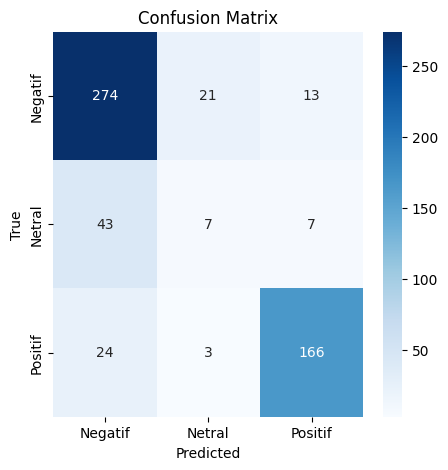

In [ ]:
# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_classes,
            yticklabels=label_classes,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()